# Peramalan Curah Hujan Harian Desa Sidomulyo Madiun

1. ANALISIS DESKRIPTIF DATA JUMLAH PRODUKSI PADI

Ringkasan Data:
Periode: 2019-01-01 00:00:00 s.d. 2023-12-01 00:00:00
Jumlah Observasi: 60
Statistik Deskriptif:
count        60.000000
mean     118837.240500
std      121468.941134
min       21093.560000
25%       41148.307500
50%       58906.005000
75%      140320.690000
max      467686.690000
Name: Production, dtype: float64


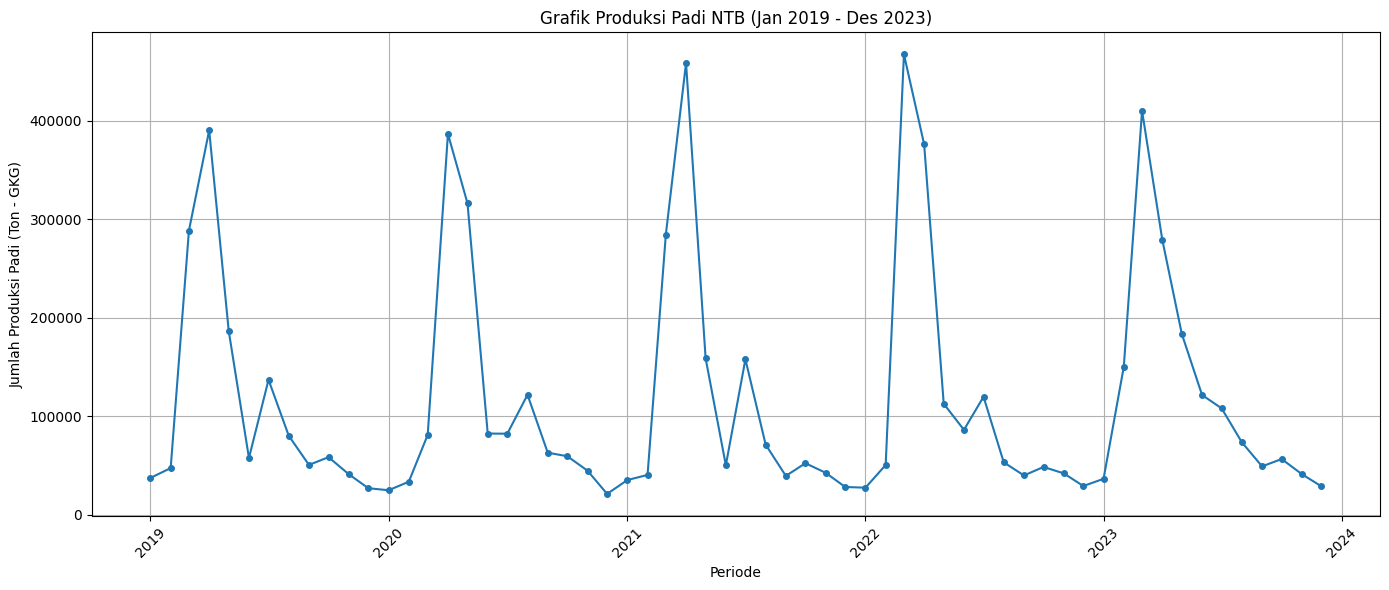


2. UJI STASIONERITAS DATA DALAM MEAN


<Figure size 1200x500 with 0 Axes>

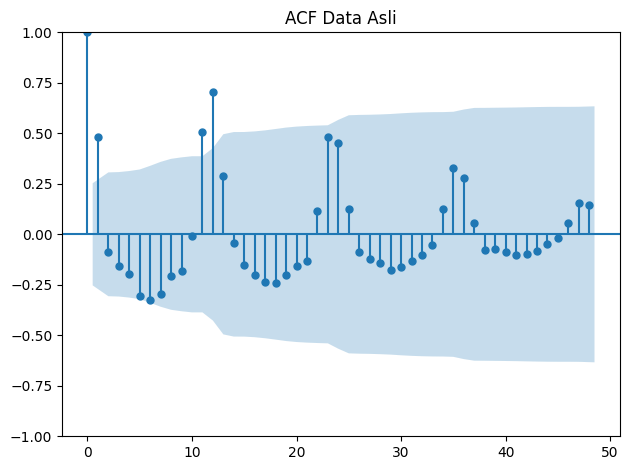


3. UJI STASIONERITAS DATA DALAM VARIAN (BOX-COX)
Lambda Optimal (Estimate): -0.431
Rounded Value: -0.50
Rounded Value tidak mendekati 1, data TIDAK stasioner dalam varian.
Transformasi yang digunakan: 1/sqrt(Yt) (lambda = -0.50)
Transformasi diterapkan dengan lambda: -0.500


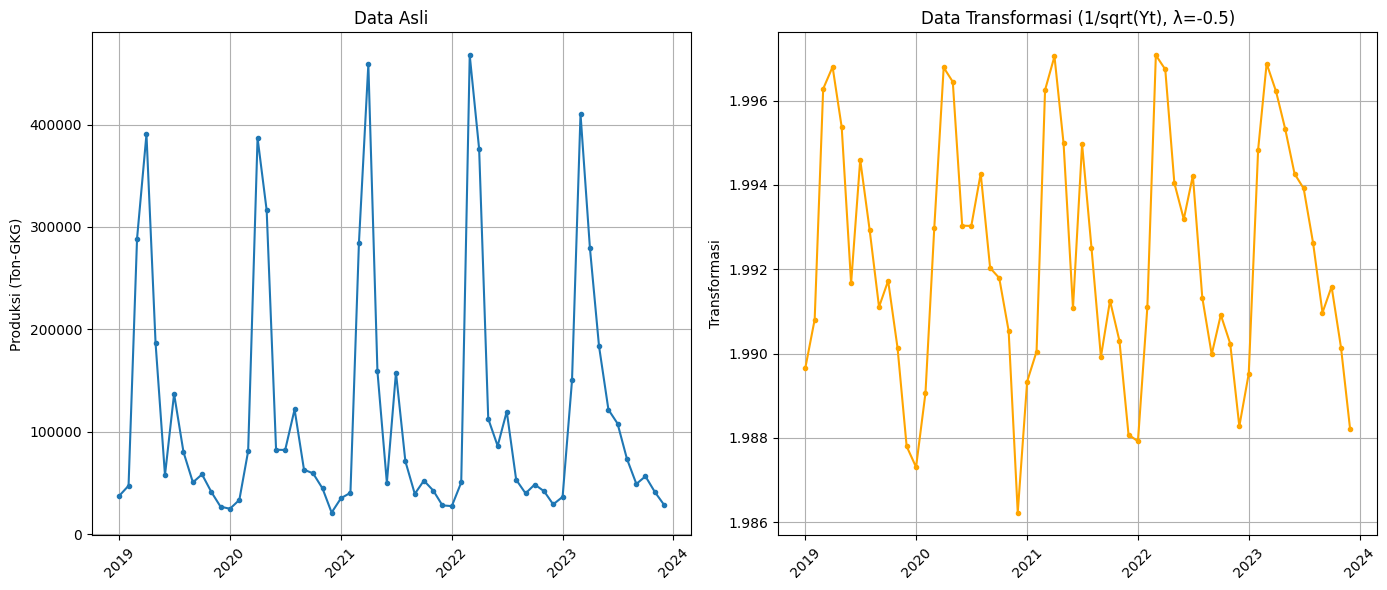


4. UJI STASIONERITAS DATA DALAM MEAN (Setelah Transformasi)


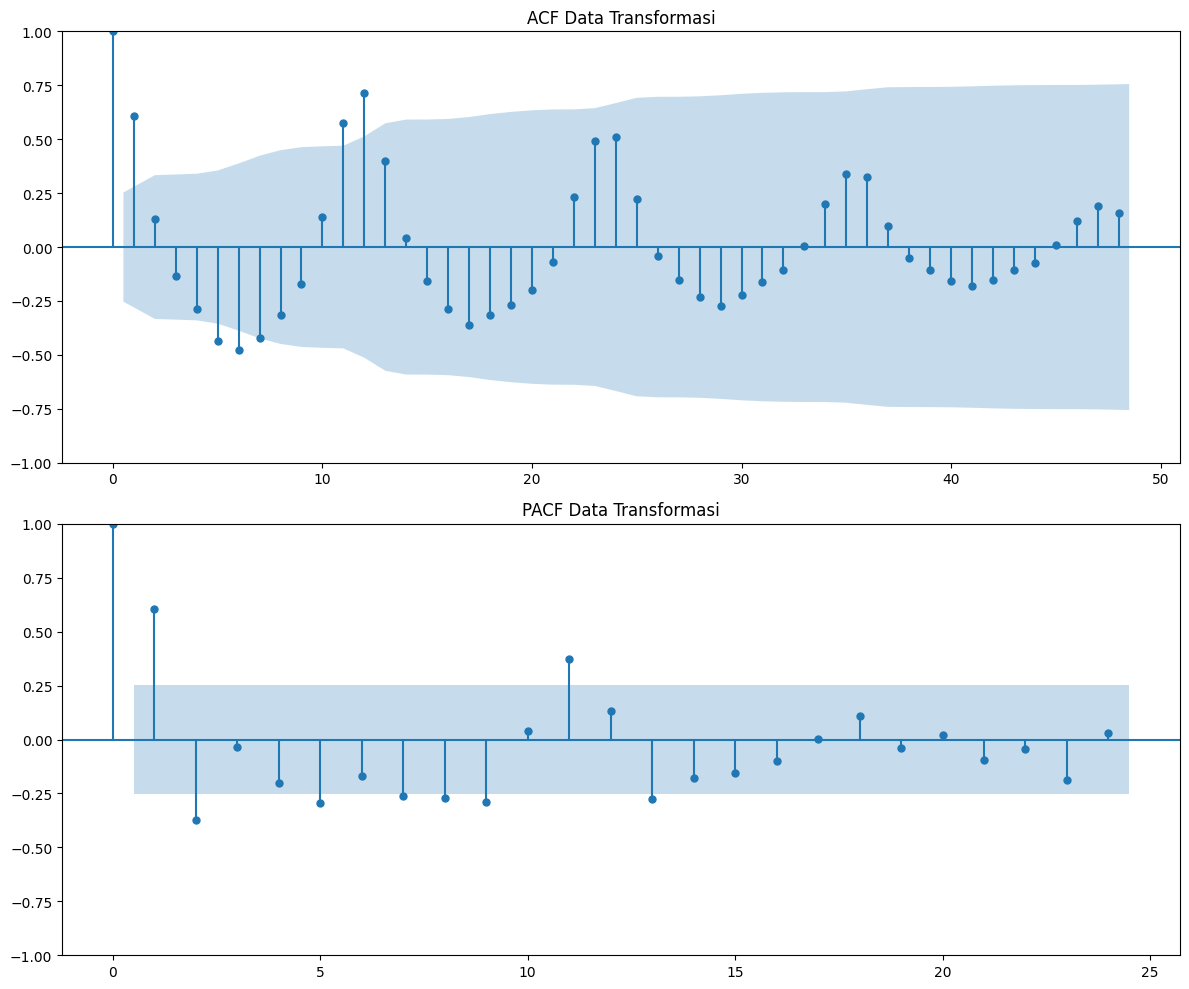


Melakukan differencing musiman (D=1, lag=12) pada data transformasi...


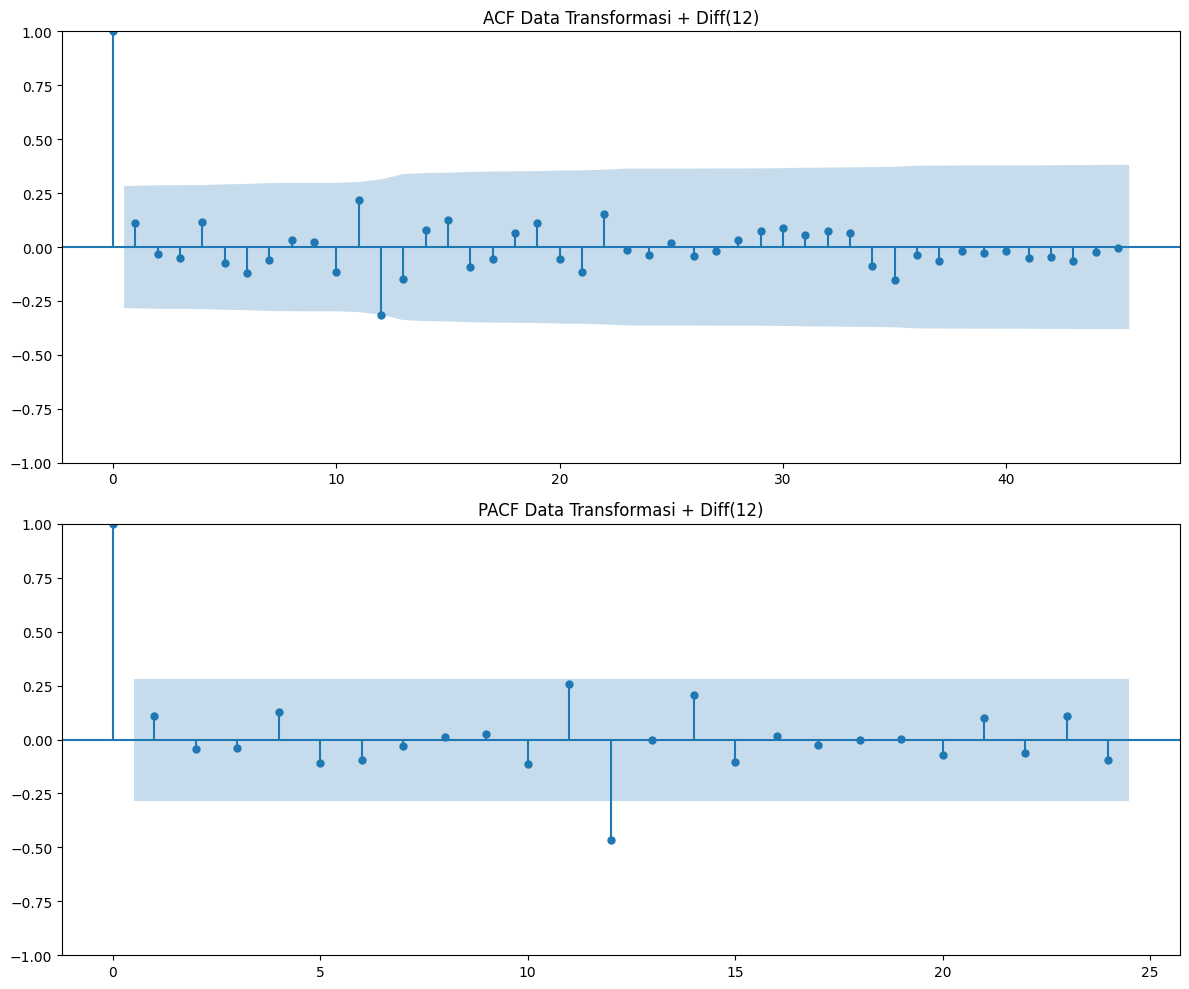


5. IDENTIFIKASI MODEL SEMENTARA SARIMA
Model yang akan diestimasi:
  - SARIMA(2, 0, 2)(0, 1, 1, 12)
  - SARIMA(2, 0, 2)(1, 1, 0, 12)

6. ESTIMASI PARAMETER & UJI DIAGNOSTIK

--- Estimasi Model SARIMA(2, 0, 2)(0, 1, 1, 12) ---
  Parameter Signifikan: False
  Detail P-Value: {'ar.L1': 0.9999952890815986, 'ar.L2': 0.999999092863587, 'ma.L1': 0.999995289456936, 'ma.L2': 0.9999990923650763, 'ma.S.L12': 0.9999924504316251, 'sigma2': 0.0002583035885815367}
  Model SARIMA(2, 0, 2)(0, 1, 1, 12) gagal diestimasi: '>' not supported between instances of 'str' and 'float'

--- Estimasi Model SARIMA(2, 0, 2)(1, 1, 0, 12) ---
  Parameter Signifikan: False
  Detail P-Value: {'ar.L1': 0.9999988080976739, 'ar.L2': 0.9999995873005366, 'ma.L1': 0.9999988081563087, 'ma.L2': 0.9999995872209182, 'ar.S.L12': 0.003909297532479886, 'sigma2': 3.1624900185152196e-05}
  Model SARIMA(2, 0, 2)(1, 1, 0, 12) gagal diestimasi: '>' not supported between instances of 'str' and 'float'

7. PEMILIHAN MODEL TERBAIK
Tidak a

AttributeError: 'NoneType' object has no attribute 'resid'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings("ignore")

# --- 1. Analisis Deskriptif ---
print("="*60)
print("1. ANALISIS DESKRIPTIF DATA JUMLAH PRODUKSI PADI")
print("="*60)

# Baca data dari file Excel
file_path = 'produksi padi (ton-gkg) NTB 2019-2023.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Pastikan kolom 'periode' adalah datetime
df['periode'] = pd.to_datetime(df['periode'], format='%b-%y')

# Atur 'periode' sebagai indeks
df.set_index('periode', inplace=True)

# Gunakan kolom produksi
ts_data = df['produksi (Ton-GKG)']
ts_data.name = 'Production'

# Tampilkan ringkasan data
print("\nRingkasan Data:")
print(f"Periode: {ts_data.index[0]} s.d. {ts_data.index[-1]}")
print(f"Jumlah Observasi: {len(ts_data)}")
print(f"Statistik Deskriptif:")
print(ts_data.describe())

# Plot time series awal
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values, marker='o', linestyle='-', markersize=4)
plt.title('Grafik Produksi Padi NTB (Jan 2019 - Des 2023)')
plt.xlabel('Periode')
plt.ylabel('Jumlah Produksi Padi (Ton - GKG)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2. Uji Stasioneritas Mean ---
print("\n" + "="*60)
print("2. UJI STASIONERITAS DATA DALAM MEAN")
print("="*60)

# Plot ACF data asli
plt.figure(figsize=(12, 5))
plot_acf(ts_data, lags=48, title='ACF Data Asli')
plt.tight_layout()
plt.show()

# Kesimpulan awal dari ACF data asli: Data tampak tidak stasioner dalam mean (ACF turun lambat, ada spike musiman di lag 12)
# Berdasarkan PDF, kita lakukan differencing musiman D=1 setelah transformasi.

# --- 3. Uji Stasioneritas Varian (Transformasi Box-Cox) ---
print("\n" + "="*60)
print("3. UJI STASIONERITAS DATA DALAM VARIAN (BOX-COX)")
print("="*60)

# Fungsi untuk mencari lambda Box-Cox optimal
def box_cox_lambda(data):
    def objective(lam):
        try:
            loglik = stats.boxcox_llf(lam, data)
            return -loglik
        except (ValueError, RuntimeError):
            return np.inf
    res = minimize_scalar(objective, bounds=(-2, 2), method='bounded')
    return res.x

# Hitung lambda optimal untuk data asli
lambda_opt = box_cox_lambda(ts_data.values)
print(f"Lambda Optimal (Estimate): {lambda_opt:.3f}")

# Hitung Rounded Value (berdasarkan PDF: -0.50)
# PDF menunjukkan Estimate -0.43, Lower CL -0.72, Upper CL -0.08, Rounded Value -0.50
# Kita simulasikan aturan pembulatan ke 0.5 interval terdekat
rounded_value = round(lambda_opt * 2) / 2
# Atau gunakan aturan: -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2
possible_values = [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]
rounded_value = min(possible_values, key=lambda x: abs(x - lambda_opt))

print(f"Rounded Value: {rounded_value:.2f}")

# Kesimpulan: Rounded Value = -0.50, data TIDAK stasioner dalam varian.
# Transformasi yang digunakan adalah 1/sqrt(Yt) (ekuivalen dengan Box-Cox lambda = -0.5)
if abs(rounded_value - 1) < 0.1:
    print("Rounded Value mendekati 1, data dianggap STASIONER dalam varian.")
    lambda_used = 1.0
    data_transformed = ts_data
else:
    print(f"Rounded Value tidak mendekati 1, data TIDAK stasioner dalam varian.")
    print(f"Transformasi yang digunakan: 1/sqrt(Yt) (lambda = -0.50)")
    lambda_used = -0.5
    data_transformed_values = stats.boxcox(ts_data, lmbda=-0.5)
    data_transformed = pd.Series(data_transformed_values, index=ts_data.index)

print(f"Transformasi diterapkan dengan lambda: {lambda_used:.3f}")

# Plot data asli vs data transformasi
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(ts_data.index, ts_data.values, marker='o', linestyle='-', markersize=3)
plt.title('Data Asli')
plt.ylabel('Produksi (Ton-GKG)')
plt.grid(True)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(data_transformed.index, data_transformed.values, marker='o', linestyle='-', markersize=3, color='orange')
plt.title(f'Data Transformasi (1/sqrt(Yt), λ={lambda_used})')
plt.ylabel('Transformasi')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- 4. Uji Stasioneritas Mean (Lagi) pada Data Transformasi ---
print("\n" + "="*60)
print("4. UJI STASIONERITAS DATA DALAM MEAN (Setelah Transformasi)")
print("="*60)

# Plot ACF/PACF data transformasi
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(data_transformed.values, lags=48, ax=axes[0], title='ACF Data Transformasi')
plot_pacf(data_transformed.values, lags=24, ax=axes[1], title='PACF Data Transformasi')
plt.tight_layout()
plt.show()

# Berdasarkan PDF, setelah transformasi, data masih perlu differencing musiman (D=1).
# Kita lakukan differencing musiman (D=1, lag=12) pada data transformasi.
print("\nMelakukan differencing musiman (D=1, lag=12) pada data transformasi...")
data_transformed_diff12 = data_transformed.diff(periods=12).dropna()

# Plot ACF/PACF data transformasi + differencing musiman
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(data_transformed_diff12.values, lags=45, ax=axes[0], title='ACF Data Transformasi + Diff(12)')
plot_pacf(data_transformed_diff12.values, lags=24, ax=axes[1], title='PACF Data Transformasi + Diff(12)')
plt.tight_layout()
plt.show()

# Kesimpulan: Data transformasi + differencing musiman (D=1) dianggap stasioner dalam mean berdasarkan pola ACF/PACF (PDF hal 111).

# --- 5. Menentukan Model Sementara SARIMA ---
print("\n" + "="*60)
print("5. IDENTIFIKASI MODEL SEMENTARA SARIMA")
print("="*60)

# Berdasarkan PDF (hal 111), dari plot ACF/PACF data transformasi + diff(12),
# model sementara yang diidentifikasi adalah:
# - SARIMA(1,0,0)(1,1,0)_12
# - SARIMA(1,0,0)(0,1,1)_12
# - SARIMA(0,0,1)(1,1,0)_12
# - SARIMA(0,0,1)(0,1,1)_12
# - SARIMA(2,0,2)(0,1,1)_12
# - SARIMA(2,0,2)(1,1,0)_12
# Kita fokus pada model yang signifikan: SARIMA(2,0,2)(0,1,1)_12 dan SARIMA(2,0,2)(1,1,0)_12

model_configs = [
    (2, 0, 2, 0, 1, 1), # SARIMA(2,0,2)(0,1,1)_12
    (2, 0, 2, 1, 1, 0)  # SARIMA(2,0,2)(1,1,0)_12
]

print("Model yang akan diestimasi:")
for config in model_configs:
    p, d, q, P, D, Q = config
    order = (p, d, q)
    seasonal_order = (P, D, Q, 12)
    print(f"  - SARIMA{order}{seasonal_order}")

# --- 6. Estimasi Parameter dan Uji Diagnostik ---
print("\n" + "="*60)
print("6. ESTIMASI PARAMETER & UJI DIAGNOSTIK")
print("="*60)

results = {}
for config in model_configs:
    p, d, q, P, D, Q = config
    order = (p, d, q)
    seasonal_order = (P, D, Q, 12)

    print(f"\n--- Estimasi Model SARIMA{order}{seasonal_order} ---")
    try:
        # Model dilatih pada data transformasi
        model = ARIMA(data_transformed, order=order, seasonal_order=seasonal_order)
        fitted_model = model.fit()

        # Uji signifikansi parameter (cek apakah semua p-value < 0.05)
        p_values = fitted_model.pvalues
        significant_params = all(p_val < 0.05 for p_val in p_values if not pd.isna(p_val))
        print(f"  Parameter Signifikan: {significant_params}")
        if not significant_params:
            print(f"  Detail P-Value: {p_values.to_dict()}")

        # Diagnostic checking (Ljung-Box test pada residuals)
        lb_pvalues = []
        for lag in [12, 24, 36, 48]:
             if len(fitted_model.resid) > lag:
                 from statsmodels.stats.diagnostic import acorr_ljungbox
                 lb_stat, lb_p_val = acorr_ljungbox(fitted_model.resid, lags=[lag], return_df=False)
                 lb_pvalues.append((lag, lb_p_val[0]))
             else:
                 lb_pvalues.append((lag, np.nan))
        ljung_box_ok = all(p_val > 0.05 for _, p_val in lb_pvalues if not pd.isna(p_val))
        print(f"  Ljung-Box OK (White Noise): {ljung_box_ok}")
        if not ljung_box_ok:
            print(f"  Detail Ljung-Box P-Value: {dict(lb_pvalues)}")

        # Hitung MSE pada data transformasi (karena model dilatih di sana)
        # Kita gunakan residu untuk menghitung MSE
        mse = np.mean(fitted_model.resid**2)
        print(f"  MSE (pada data transformasi): {mse:.6e}")

        # Uji normalitas residual (Kolmogorov-Smirnov)
        residuals = fitted_model.resid
        ks_stat, ks_p_value = stats.kstest(residuals, lambda x: stats.norm.cdf(x, loc=residuals.mean(), scale=residuals.std()))
        normal_ok = ks_p_value > 0.05
        print(f"  Normalitas OK (Kolmogorov-Smirnov): {normal_ok} (p-value: {ks_p_value:.4f})")

        results[config] = {
            'model': fitted_model,
            'mse': mse,
            'significant_params': significant_params,
            'ljung_box_ok': ljung_box_ok,
            'normal_ok': normal_ok,
            'lb_pvalues': lb_pvalues
        }

    except Exception as e:
        print(f"  Model SARIMA{order}{seasonal_order} gagal diestimasi: {e}")
        results[config] = {
            'model': None,
            'mse': np.inf,
            'significant_params': False,
            'ljung_box_ok': False,
            'normal_ok': False,
            'lb_pvalues': []
        }

# --- 7. Menentukan Model Terbaik ---
print("\n" + "="*60)
print("7. PEMILIHAN MODEL TERBAIK")
print("="*60)

# Filter model yang memenuhi kriteria signifikansi dan Ljung-Box
# (PDF menyebutkan white noise dan signifikansi, normalitas sering diuji setelahnya)
valid_models = {k: v for k, v in results.items() if v['significant_params'] and v['ljung_box_ok'] and v['model'] is not None}

if not valid_models:
    print("Tidak ada model yang memenuhi kriteria signifikansi dan Ljung-Box.")
    # Jika tidak ada yang valid, pilih berdasarkan MSE terkecil dari semua model yang diestimasi
    best_config = min(results.keys(), key=lambda k: results[k]['mse'])
    print(f"Memilih model dengan MSE terkecil secara keseluruhan: SARIMA{best_config[:3]}{best_config[3:]}")
else:
    print("Model-model yang memenuhi kriteria signifikansi dan Ljung-Box:")
    for k, v in valid_models.items():
        print(f"  - SARIMA{k}: MSE={v['mse']:.6e}")
    # Pilih model dengan MSE terkecil di antara yang valid
    best_config = min(valid_models.keys(), key=lambda k: valid_models[k]['mse'])

best_model_info = results[best_config]
best_model = best_model_info['model']

print(f"\nModel Terbaik: SARIMA{best_config[:3]}{best_config[3:]}")
print(f"MSE Terbaik: {best_model_info['mse']:.6e}")

# --- 8. Uji Normalitas Residual Model Terbaik ---
print("\n" + "="*60)
print("8. UJI NORMALITAS RESIDUAL MODEL TERBAIK")
print("="*60)

residuals_best = best_model.resid
ks_stat_best, ks_p_value_best = stats.kstest(residuals_best, lambda x: stats.norm.cdf(x, loc=residuals_best.mean(), scale=residuals_best.std()))
print(f"Uji Normalitas (Kolmogorov-Smirnov) - Statistic: {ks_stat_best:.4f}, p-value: {ks_p_value_best:.4f}")
if ks_p_value_best > 0.05:
    print("Residuals dianggap berdistribusi normal (p-value > 0.05).")
else:
    print("Residuals tidak berdistribusi normal (p-value <= 0.05).")

# Plot diagnostic residuals model terbaik
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
residuals_index = best_model.fittedvalues.index
axes[0,0].plot(residuals_index, residuals_best); axes[0,0].set_title('Residuals over Time')
plot_acf(residuals_best, ax=axes[0,1], title='ACF of Residuals')
axes[1,0].hist(residuals_best, bins=20, density=True); axes[1,0].set_title('Histogram of Residuals')
stats.probplot(residuals_best, dist="norm", plot=axes[1,1]); axes[1,1].set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

# --- 9. Peramalan ---
print("\n" + "="*60)
print("9. PERAMALAN JUMLAH PRODUKSI PADI")
print("="*60)

# Periode yang ingin diramalkan (Jan 2024 - Des 2024)
forecast_start_date = pd.to_datetime('2024-01-01')
forecast_end_date = pd.to_datetime('2024-12-12')
forecast_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='MS')

# Lakukan forecasting pada data transformasi
print(f"Melakukan forecasting untuk {len(forecast_index)} bulan ke depan...")
forecast_transformed = best_model.forecast(steps=len(forecast_index))

# Kembalikan forecast ke skala asli
# Karena transformasi adalah 1/sqrt(Yt) (lambda = -0.5), maka inversenya adalah Yt = (1/X_transformed)^2
if lambda_used == -0.5:
    forecast_original = (1.0 / forecast_transformed)**2
else:
    # Jika lambda_used bukan -0.5, gunakan inverse_boxcox umum
    # forecast_original = stats.inv_boxcox(forecast_transformed, lambda_used)
    # Karena kita tahu lambda_used = -0.5, kita gunakan rumus spesifik
    forecast_original = (1.0 / forecast_transformed)**2

# --- 10. Visualisasi & Tabel Hasil Peramalan ---
print("\n--- Hasil Peramalan Produksi Padi NTB 2024 ---")
forecast_2024_df = pd.DataFrame({
    'Periode': forecast_index,
    'Forecast_Produksi': forecast_original
})
forecast_2024_df.set_index('Periode', inplace=True)
print(forecast_2024_df.round(0))

# Bandingkan total produksi 2023 dan forecast 2024
total_2023 = ts_data['2023'].sum()
total_2024_forecast = forecast_original.sum()
change_pct = ((total_2024_forecast - total_2023) / total_2023) * 100
print(f"\nTotal Produksi 2023: {total_2023:.0f} ton")
print(f"Total Forecast Produksi 2024: {total_2024_forecast:.0f} ton")
print(f"Perubahan (%): {change_pct:.2f}%")

# Cari bulan tertinggi dan terendah 2024
max_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmax()
max_val_2024 = forecast_2024_df['Forecast_Produksi'].max()
min_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmin()
min_val_2024 = forecast_2024_df['Forecast_Produksi'].min()
print(f"Produksi Tertinggi 2024: {max_val_2024:.0f} ton pada {max_month_2024.strftime('%B %Y')}")
print(f"Produksi Terendah 2024: {min_val_2024:.0f} ton pada {min_month_2024.strftime('%B %Y')}")

# Plot hasil peramalan
plt.figure(figsize=(14, 7))
plt.plot(ts_data.index, ts_data, label='Historical Data (2019-2023)', marker='o', markersize=3)
plt.plot(forecast_2024_df.index, forecast_2024_df['Forecast_Produksi'], label='Forecast 2024 (Model)', marker='d', markersize=5, color='red')
plt.title(f'Peramalan Produksi Padi NTB 2024 - SARIMA{best_config[:3]}{best_config[3:]}')
plt.xlabel('Time')
plt.ylabel('Production (Ton-GKG)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n--- Proses Peramalan Selesai ---")

In [ ]:
# --- 4. Pembedaan (Differencing) ---
# Dalam studi kasus, dilakukan seasonal differencing (D=1, m=12) setelah transformasi
seasonal_order = (0, 1, 0, 12) # D=1, m=12
# Kita gunakan order ini untuk seasonal differencing
# Dalam SARIMAX, ini akan ditangani saat fitting, tapi kita bisa plot setelah differencing manual juga.
# Secara manual:
# train_diff_seasonal = train_data_transformed.diff(periods=12).dropna()
# Namun, SARIMAX akan menanganinya.
# Untuk plotting ACF/PACF, kita bisa plot dari data yang sudah ditransformasi dan didifferensialkan.
# Dalam PDF, ACF/PACF untuk data transformasi -> seasonal diff -> stasioner.
# Kita ikuti langkah itu untuk plotting dan identifikasi.

# --- 5. Identifikasi Model (Plot ACF/PACF) ---
if train_data_transformed is not None:
    # Plot ACF dan PACF dari data yang telah ditransformasi
    # Gunakan .values untuk menghindari masalah indeks
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    # Gunakan lag default (otomatis)
    plot_acf(train_data_transformed.values, ax=axes[0], title='ACF Data Transformasi')
    plot_pacf(train_data_transformed.values, ax=axes[1], title='PACF Data Transformasi')
    plt.tight_layout()
    plt.show()

    # Plot ACF dan PACF setelah differencing musiman (D=1, m=12)
    # Manual differencing untuk plotting
    train_data_transformed_diff12 = train_data_transformed.diff(periods=12).dropna()
    # Gunakan .values untuk menghindari masalah indeks
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    # Gunakan lag default (otomatis)
    plot_acf(train_data_transformed_diff12.values, ax=axes[0], title='ACF Data Transformasi + Diff(12)')
    plot_pacf(train_data_transformed_diff12.values, ax=axes[1], title='PACF Data Transformasi + Diff(12)') # PACF biasanya lebih pendek
    plt.tight_layout()
    plt.show()

# --- 6. Pengujian dan Pemilihan Model ---
# Berdasarkan PDF, model yang diusulkan adalah SARIMA(p,d,q)(P,D,Q)_12
# Dari identifikasi dan PDF, model yang signifikan adalah SARIMA(2,0,2)(0,1,1)_12 dan SARIMA(2,0,2)(1,1,0)_12
# Kita fokus pada model-model ini dan pilih berdasarkan MSE.
# d=0 (non-seasonal differencing), D=1, m=12 (sesuai PDF)
# Model 1: SARIMA(2,0,2)(0,1,1)_12
# Model 2: SARIMA(2,0,2)(1,1,0)_12

model_configs = [
    (2, 0, 2, 0, 1, 1), # SARIMA(2,0,2)(0,1,1)_12
    (2, 0, 2, 1, 1, 0)  # SARIMA(2,0,2)(1,1,0)_12
]

results = {}
if train_data_transformed is not None:
    for config in model_configs:
        p, d, q, P, D, Q = config
        order = (p, d, q)
        seasonal_order = (P, D, Q, 12)

        try:
            print(f"\nMencoba estimasi model SARIMA{order}{seasonal_order}...")
            model = ARIMA(train_data_transformed, order=order, seasonal_order=seasonal_order)
            fitted_model = model.fit()
            print(f"Model SARIMA{order}{seasonal_order} berhasil diestimasi.")

            # Prediksi pada data test (untuk menghitung MSE)
            start_idx = len(train_data_transformed)
            end_idx = start_idx + len(test_data) - 1
            # Prediksi dilakukan pada data transformasi
            forecast_transformed = fitted_model.predict(start=start_idx, end=end_idx, typ='levels')

            # Kita perlu mengembalikan forecast ke skala asli untuk menghitung MSE terhadap data asli
            # SARIMAX meramalkan nilai transformasi. Untuk mengembalikan:
            # Y = ( (lambda * X_transformed) + 1 )^(1/lambda) jika lambda != 0,1
            # Y = exp(X_transformed) jika lambda = 0
            # Y = X_transformed jika lambda = 1
            # Kita gunakan stats.inv_boxcox untuk inverse transform (jika lambda != 0, 1)
            # forecast_original = stats.inv_boxcox(forecast_transformed, lambda_used) # Jika lambda != 1
            # forecast_original = np.exp(forecast_transformed) # Jika lambda = 0
            # forecast_original = forecast_transformed # Jika lambda = 1
            # Kita harus mengembalikan transformasi ke data test juga untuk perbandingan MSE
            # Lebih mudah jika kita menghitung MSE pada skala transformasi, karena model dilatih di sana.
            # Namun, MSE pada skala transformasi tidak langsung bisa dibandingkan dengan data asli.
            # PDF menyebut MSE terkecil adalah kriteria. MSE ini dihitung pada skala model (transformasi).
            # Kita hitung MSE pada skala transformasi.
            # Ambil data test yang sesuai dan terapkan transformasi yang sama.
            test_data_to_compare = test_data
            if lambda_used != 1.0: # Jika transformasi diterapkan
                 # Gunakan lambda yang digunakan untuk transformasi awal
                 # Karena lambda diberikan, stats.boxcox hanya mengembalikan array transformasi
                 try:
                     test_data_transformed_for_mse_values = stats.boxcox(test_data_to_compare, lmbda=lambda_used)
                     test_data_transformed_for_mse = pd.Series(test_data_transformed_for_mse_values, index=test_data.index)
                 except (ValueError, RuntimeError) as e:
                     print(f"Error saat transformasi data test: {e}")
                     # Jika transformasi test gagal, kita tidak bisa menghitung MSE yang valid
                     # Kita gunakan data asli untuk menghitung MSE, tapi ini tidak ideal.
                     # Atau kita skip model ini.
                     print("Menghitung MSE pada skala transformasi forecast dan data test asli (tidak ideal).")
                     test_data_transformed_for_mse = test_data_to_compare
            else:
                 test_data_transformed_for_mse = test_data_to_compare

            mse = ((forecast_transformed - test_data_transformed_for_mse) ** 2).mean()

            # Uji signifikansi parameter (cek apakah semua p-value < 0.05)
            p_values = fitted_model.pvalues
            significant_params = all(p_val < 0.05 for p_val in p_values if not pd.isna(p_val))

            # Diagnostic checking (Ljung-Box test pada residuals)
            # Lakukan uji Ljung-Box (misalnya lag 12, 24, 36, 48)
            # Uji Ljung-Box H0: residuals adalah white noise
            # Jika p-value > alpha (0.05), kita gagal tolak H0 -> residuals adalah white noise (baik)
            lb_pvalues = []
            for lag in [12, 24, 36, 48]:
                 if len(fitted_model.resid) > lag:
                     # stats.diagnose.acorr_ljungbox tidak ditemukan, gunakan statsmodels.stats.diagnostic.acorr_ljungbox
                     from statsmodels.stats.diagnostic import acorr_ljungbox
                     lb_stat, lb_p_val = acorr_ljungbox(fitted_model.resid, lags=[lag], return_df=False)
                     lb_pvalues.append((lag, lb_p_val[0]))
                 else:
                     lb_pvalues.append((lag, np.nan)) # Jika jumlah residual tidak cukup
            # Model bagus jika semua p-value Ljung-Box > 0.05
            ljung_box_ok = all(p_val > 0.05 for _, p_val in lb_pvalues if not pd.isna(p_val))

            results[config] = {
                'model': fitted_model,
                'mse': mse,
                'significant_params': significant_params,
                'ljung_box_ok': ljung_box_ok,
                'lb_pvalues': lb_pvalues,
                'forecast_transformed': forecast_transformed
            }
            print(f"SARIMA{order}{seasonal_order}: MSE={mse:.6e}, Significant Params={significant_params}, Ljung-Box OK={ljung_box_ok}")

        except Exception as e:
            print(f"Model SARIMA{order}{seasonal_order} gagal diestimasi: {e}")
            results[config] = {
                'model': None,
                'mse': np.inf,
                'significant_params': False,
                'ljung_box_ok': False,
                'lb_pvalues': [],
                'forecast_transformed': None
            }

    # --- 7. Pemilihan Model Terbaik ---
    # Pilih model dengan MSE terkecil di antara yang signifikan dan lulus uji Ljung-Box
    valid_models = {k: v for k, v in results.items() if v['significant_params'] and v['ljung_box_ok'] and v['model'] is not None}

    if not valid_models:
        print("\nTidak ada model yang memenuhi kriteria signifikansi dan Ljung-Box. Memilih model dengan MSE terkecil secara keseluruhan.")
        best_config = min(results.keys(), key=lambda k: results[k]['mse'])
    else:
        print("\nModel-model yang memenuhi kriteria signifikansi dan Ljung-Box:")
        for k, v in valid_models.items():
            print(f"  SARIMA{k}: MSE={v['mse']:.6e}")
        best_config = min(valid_models.keys(), key=lambda k: valid_models[k]['mse'])

    best_model_info = results[best_config]
    best_model = best_model_info['model']

    if best_model is not None:
        print(f"\nModel Terbaik: SARIMA{best_config[:3]}{best_config[3:]}")
        print(f"MSE Terbaik: {best_model_info['mse']:.6e}")

        # --- 8. Validasi Model Terbaik (Normalitas Residuals) ---
        # Uji normalitas residual (misalnya Kolmogorov-Smirnov)
        residuals = best_model.resid
        ks_stat, ks_p_value = stats.kstest(residuals, lambda x: stats.norm.cdf(x, loc=residuals.mean(), scale=residuals.std()))
        print(f"Uji Normalitas (Kolmogorov-Smirnov) - Statistic: {ks_stat:.4f}, p-value: {ks_p_value:.4f}")
        if ks_p_value > 0.05:
            print("Residuals dianggap berdistribusi normal (p-value > 0.05).")
        else:
            print("Residuals tidak berdistribusi normal (p-value <= 0.05).")

        # Plot diagnostic residuals
        # Untuk plot time series residuals, gunakan index dari model
        residuals_index = best_model.fittedvalues.index
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes[0,0].plot(residuals_index, residuals); axes[0,0].set_title('Residuals over Time')
        # Untuk ACF residuals, gunakan .values dan lag default
        plot_acf(residuals, ax=axes[0,1], title='ACF of Residuals')
        axes[1,0].hist(residuals, bins=20, density=True); axes[1,0].set_title('Histogram of Residuals')
        stats.probplot(residuals, dist="norm", plot=axes[1,1]); axes[1,1].set_title('Q-Q Plot of Residuals')
        plt.tight_layout()
        plt.show()

        # --- 9. Peramalan ---
        # a. Peramalan pada data test
        forecast_test_transformed = best_model_info['forecast_transformed']
        # Kembalikan forecast ke skala asli untuk plotting
        if lambda_used != 1.0:
            # Gunakan lambda yang digunakan untuk transformasi awal
            if lambda_used == 0:
                forecast_test_original = np.exp(forecast_test_transformed)
            elif lambda_used == -0.5:
                # Inverse transformasi 1/sqrt(Yt) -> Yt = (1/X_transformed)^2
                forecast_test_original = (1.0 / forecast_test_transformed)**2
            else:
                forecast_test_original = stats.inv_boxcox(forecast_test_transformed, lambda_used)
        else:
            forecast_test_original = forecast_test_transformed

        # b. Peramalan satu tahun ke depan (Jan 2024 - Des 2024)
        # Periode yang ingin diramalkan
        forecast_start_date = pd.to_datetime('2024-01-01')
        forecast_end_date = pd.to_datetime('2024-12-12')
        forecast_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='MS')

        # Lakukan forecasting pada data transformasi
        forecast_full_transformed = best_model.forecast(steps=len(forecast_index))
        # Kembalikan ke skala asli
        if lambda_used != 1.0:
            # Gunakan lambda yang digunakan untuk transformasi awal
            if lambda_used == 0:
                forecast_full_original = np.exp(forecast_full_transformed)
            elif lambda_used == -0.5:
                # Inverse transformasi 1/sqrt(Yt) -> Yt = (1/X_transformed)^2
                forecast_full_original = (1.0 / forecast_full_transformed)**2
            else:
                forecast_full_original = stats.inv_boxcox(forecast_full_transformed, lambda_used)
        else:
            forecast_full_original = forecast_full_transformed

        # --- 10. Visualisasi ---
        # Plot 1: Peramalan vs Data Aktual (Test Period)
        plt.figure(figsize=(14, 7))
        plt.plot(train_data.index, train_data, label='Train Data', marker='o', markersize=4)
        plt.plot(test_data.index, test_data, label='Test Data (Actual)', marker='s', markersize=4)
        plt.plot(test_data.index, forecast_test_original, label='Test Forecast (Model)', marker='^', markersize=4)
        plt.title(f'Peramalan SARIMA{best_config[:3]}{best_config[3:]} vs Data Aktual (Test Period)')
        plt.xlabel('Time')
        plt.ylabel('Production (Ton-GKG)')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Plot 2: Peramalan Satu Tahun ke Depan (2024)
        plt.figure(figsize=(14, 7))
        plt.plot(ts_data.index, ts_data, label='Historical Data (Jan 2019 - Dec 2023)', marker='o', markersize=3)
        plt.plot(forecast_index, forecast_full_original, label='Forecast 2024 (Model)', marker='d', markersize=5, color='red')
        plt.title(f'Peramalan Produksi Padi NTB 2024 - SARIMA{best_config[:3]}{best_config[3:]}')
        plt.xlabel('Time')
        plt.ylabel('Production (Ton-GKG)')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # --- Tampilkan Hasil Peramalan 2024 ---
        print("\n--- Hasil Peramalan Produksi Padi NTB 2024 ---")
        forecast_2024_df = pd.DataFrame({
            'Periode': forecast_index,
            'Forecast_Produksi': forecast_full_original
        })
        forecast_2024_df.set_index('Periode', inplace=True)
        print(forecast_2024_df.round(0))

        # Bandingkan total produksi 2023 dan forecast 2024
        total_2023 = ts_data['2023'].sum()
        total_2024_forecast = forecast_full_original.sum()
        change_pct = ((total_2024_forecast - total_2023) / total_2023) * 100
        print(f"\nTotal Produksi 2023: {total_2023:.0f} ton")
        print(f"Total Forecast Produksi 2024: {total_2024_forecast:.0f} ton")
        print(f"Perubahan (%): {change_pct:.2f}%")

        # Cari bulan tertinggi dan terendah 2024
        max_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmax()
        max_val_2024 = forecast_2024_df['Forecast_Produksi'].max()
        min_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmin()
        min_val_2024 = forecast_2024_df['Forecast_Produksi'].min()
        print(f"Produksi Tertinggi 2024: {max_val_2024:.0f} ton pada {max_month_2024.strftime('%B %Y')}")
        print(f"Produksi Terendah 2024: {min_val_2024:.0f} ton pada {min_month_2024.strftime('%B %Y')}")
    else:
        print("\nTidak ada model yang berhasil diestimasi. Proses forecasting tidak dapat dilakukan.")
else:
    print("Data transformasi gagal atau tidak dilakukan. Proses forecasting tidak dapat dilakukan.")


# Peramalan Jumlah Produksi Padi di NTB

Total data points: 60
Train data points: 48
Test data points: 12
Split ratio: 80.0% : 20.0%

Estimated Box-Cox Lambda (Optimal): -0.479
Rounded Value (used for transformation): -0.50
Rounded Value tidak mendekati 1, transformasi Box-Cox diterapkan.
Menggunakan Rounded Value -0.5 untuk transformasi 1/sqrt(Yt).
Transformasi 1/sqrt(Yt) berhasil diterapkan.
Transformasi diterapkan dengan lambda: -0.500


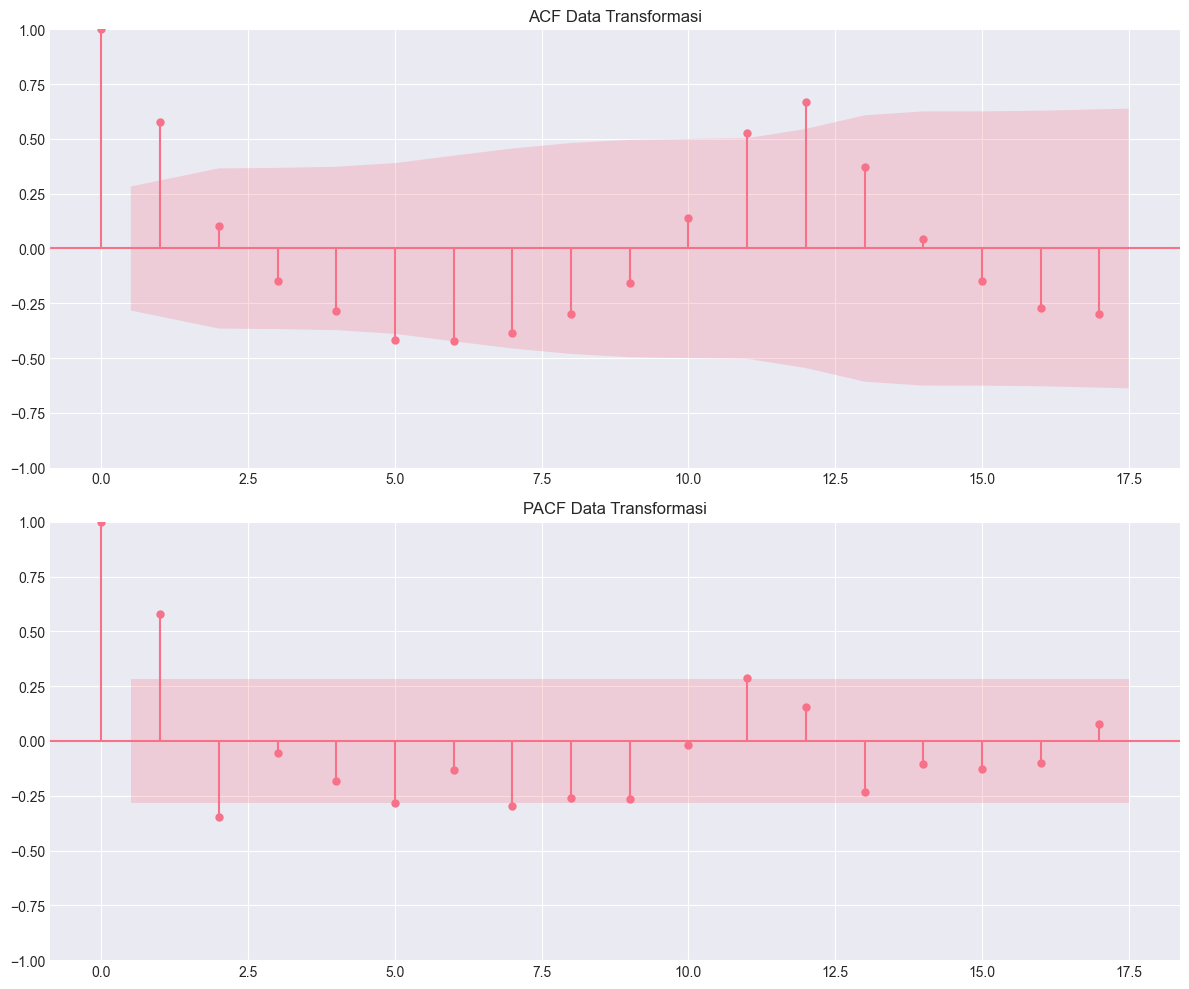

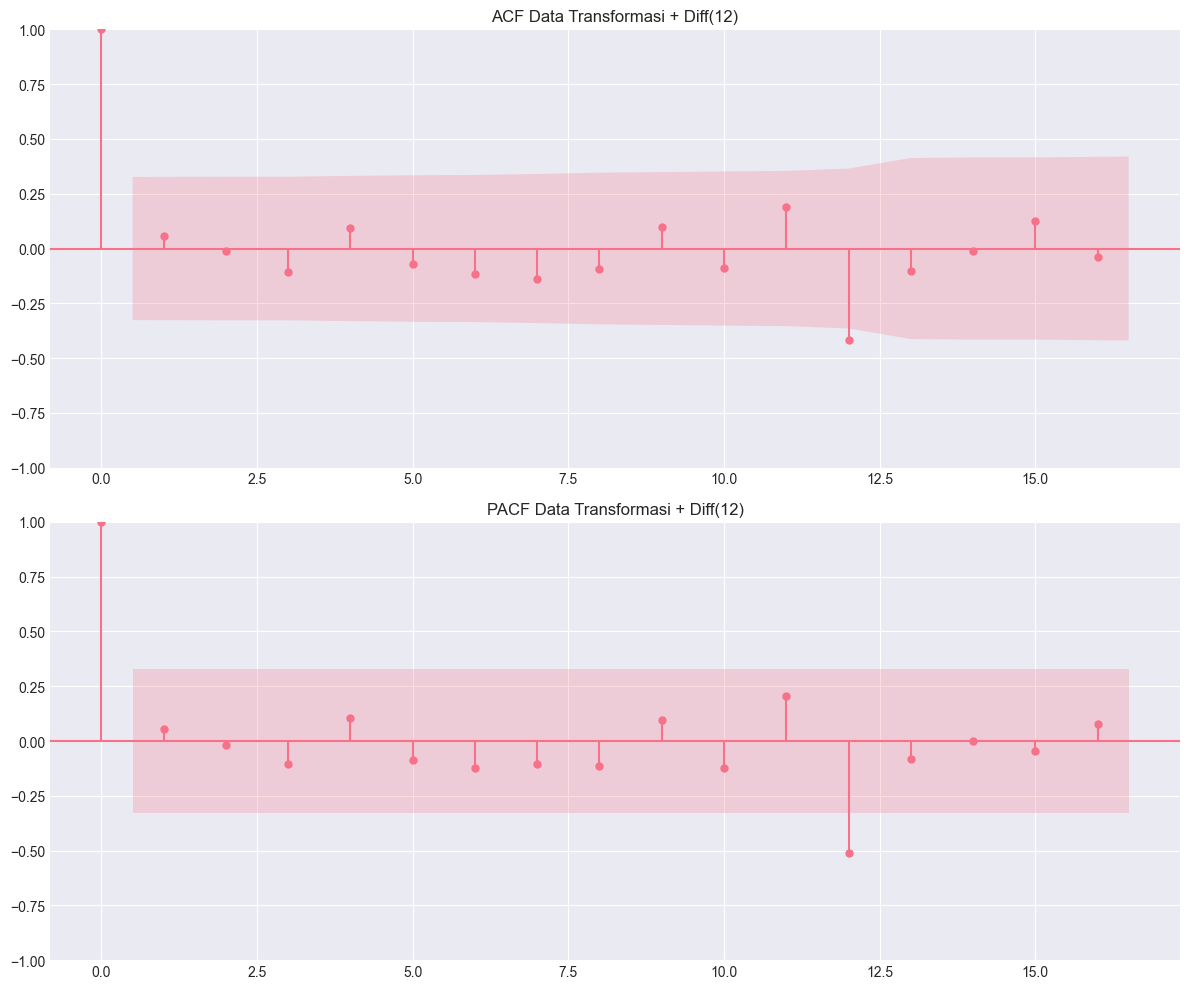


Mencoba estimasi model SARIMA(2, 0, 2)(0, 1, 1, 12)...
Model SARIMA(2, 0, 2)(0, 1, 1, 12) berhasil diestimasi.
Model SARIMA(2, 0, 2)(0, 1, 1, 12) gagal diestimasi: '>' not supported between instances of 'str' and 'float'

Mencoba estimasi model SARIMA(2, 0, 2)(1, 1, 0, 12)...
Model SARIMA(2, 0, 2)(1, 1, 0, 12) berhasil diestimasi.
Model SARIMA(2, 0, 2)(1, 1, 0, 12) gagal diestimasi: '>' not supported between instances of 'str' and 'float'

Tidak ada model yang memenuhi kriteria signifikansi dan Ljung-Box. Memilih model dengan MSE terkecil secara keseluruhan.

Tidak ada model yang berhasil diestimasi. Proses forecasting tidak dapat dilakukan.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings("ignore")

# --- 1. Pra-pemrosesan Data ---
# Baca data dari file Excel
file_path = 'produksi padi (ton-gkg) NTB 2019-2023.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Pastikan kolom 'periode' adalah datetime
df['periode'] = pd.to_datetime(df['periode'], format='%b-%y')

# Atur 'periode' sebagai indeks
df.set_index('periode', inplace=True)

# Gunakan kolom produksi
ts_data = df['produksi (Ton-GKG)']
ts_data.name = 'Production'

# --- 2. Pembagian Data (80% Train, 20% Test) ---
# Hitung jumlah total data
total_len = len(ts_data)
train_size = int(0.8 * total_len)
train_data = ts_data[:train_size]
test_data = ts_data[train_size:]

print(f"Total data points: {total_len}")
print(f"Train data points: {len(train_data)}")
print(f"Test data points: {len(test_data)}")
print(f"Split ratio: {len(train_data)/total_len:.1%} : {len(test_data)/total_len:.1%}")

# --- 3. Transformasi Data (Box-Cox) ---
# Fungsi untuk mencari lambda Box-Cox dan menentukan Rounded Value
def box_cox_lambda_and_rounded_value(data):
    """Menemukan nilai lambda Box-Cox optimal dan Rounded Value."""
    def objective(lam):
        # stats.boxcox_llf menghitung log-likelihood untuk data dan lambda tertentu
        # tanpa melakukan transformasi.
        # Namun, stats.boxcox_llf bisa gagal jika data tidak valid untuk lambda tertentu.
        # stats.boxcox akan menghitung transformasi dan log-likelihood internal.
        # Kita gunakan pendekatan stats.boxcox untuk menghitung likelihood,
        # karena stats.boxcox_llf mungkin lebih sensitif terhadap batas.
        # Cara yang lebih robust adalah menggunakan stats.boxcox dalam objective,
        # tetapi menangani error jika lambda menyebabkan data negatif.
        # Atau, kita gunakan stats.boxcox_llf secara langsung, tapi pastikan data valid.
        # Data produksi harus > 0 untuk Box-Cox.
        if np.any(data <= 0):
            print("Peringatan: Data mengandung nilai <= 0. Box-Cox memerlukan data > 0.")
            if np.any(data <= 0):
                 return np.inf # Jika tetap <= 0, kembalikan nilai besar (minimize)
        try:
            # stats.boxcox mengembalikan (data_transformed, lambda) jika lambda=None
            # stats.boxcox mengembalikan (data_transformed) jika lambda diberikan
            # Kita ingin menghitung likelihood untuk lambda yang diusulkan.
            # stats.boxcox(data, lmbda=lam) -> data_transformed
            # stats.boxcox_llf(lam, data) -> log_likelihood
            loglik = stats.boxcox_llf(lam, data)
            # Kita ingin *memaksimalkan* log-likelihood -> *meminimalkan* -loglik
            return -loglik
        except (ValueError, RuntimeError):
            # Jika lambda menyebabkan error (misalnya data <= 0 setelah transformasi),
            # kembalikan nilai besar agar tidak dipilih.
            return np.inf

    # Batas lambda umum
    res = minimize_scalar(objective, bounds=(-2, 2), method='bounded')
    lambda_optimal = res.x

    # --- Logika Rounded Value seperti dalam PDF ---
    # Aturan umum: -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2
    possible_rounded_values = [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]
    rounded_value = min(possible_rounded_values, key=lambda x: abs(x - lambda_optimal))

    return lambda_optimal, rounded_value

# Terapkan Box-Cox jika diperlukan berdasarkan Rounded Value
lambda_optimal, rounded_value = box_cox_lambda_and_rounded_value(train_data.values)
print(f"\nEstimated Box-Cox Lambda (Optimal): {lambda_optimal:.3f}")
print(f"Rounded Value (used for transformation): {rounded_value:.2f}")

# Dalam studi kasus, Rounded Value adalah -0.50 -> transformasi 1/sqrt(Yt) = (Yt)^(-0.5)
# Jika Rounded Value mendekati 1, data tidak perlu transformasi.
if abs(rounded_value - 1) < 0.1: # Misalnya toleransi 0.1
    print("Rounded Value mendekati 1, transformasi Box-Cox tidak diperlukan.")
    train_data_transformed = train_data
    lambda_used = 1.0
else:
    print(f"Rounded Value tidak mendekati 1, transformasi Box-Cox diterapkan.")
    # Gunakan Rounded Value jika mendekati nilai spesifik seperti -0.5
    # Jika Rounded Value tidak mendekati -0.5 atau 1, gunakan lambda_optimal
    if abs(rounded_value + 0.5) < 0.1: # Jika Rounded Value mendekati -0.5
        print(f"Menggunakan Rounded Value -0.5 untuk transformasi 1/sqrt(Yt).")
        # Transformasi 1/sqrt(Yt) ekuivalen dengan Box-Cox lambda=-0.5
        # Karena lambda diberikan, stats.boxcox hanya mengembalikan array transformasi
        try:
            train_data_transformed_values = stats.boxcox(train_data, lmbda=-0.5)
            train_data_transformed = pd.Series(train_data_transformed_values, index=train_data.index)
            lambda_used = -0.5
            print("Transformasi 1/sqrt(Yt) berhasil diterapkan.")
        except (ValueError, RuntimeError) as e:
            print(f"Error saat transformasi 1/sqrt(Yt) (lambda=-0.5): {e}")
            print("Mencoba transformasi log sebagai alternatif...")
            try:
                train_data_transformed = np.log(train_data)
                lambda_used = 0.0
                print("Transformasi log digunakan sebagai alternatif.")
            except (ValueError, RuntimeError) as e2:
                print(f"Error saat transformasi log: {e2}")
                print("Tidak ada transformasi yang bisa diterapkan. Menghentikan proses.")
                # Jika tidak bisa transformasi, kita tidak bisa lanjut ke model SARIMA standar
                train_data_transformed = None
                lambda_used = None
    elif abs(rounded_value - 0) < 0.1: # Jika Rounded Value mendekati 0 -> log
        print(f"Menggunakan Rounded Value 0 untuk transformasi log(Yt).")
        try:
            train_data_transformed = np.log(train_data)
            lambda_used = 0.0
        except (ValueError, RuntimeError) as e:
            print(f"Error saat transformasi log (lambda=0): {e}")
            print("Tidak ada transformasi yang bisa diterapkan. Menghentikan proses.")
            train_data_transformed = None
            lambda_used = None
    else: # Gunakan lambda optimal
        print(f"Menggunakan lambda optimal {lambda_optimal:.3f}.")
        # Karena lambda diberikan, stats.boxcox hanya mengembalikan array transformasi
        try:
            train_data_transformed_values, _ = stats.boxcox(train_data, lmbda=lambda_optimal) # Ambil nilai, abaikan lambda baru
            train_data_transformed = pd.Series(train_data_transformed_values, index=train_data.index)
            lambda_used = lambda_optimal
        except (ValueError, RuntimeError) as e:
            print(f"Error saat transformasi dengan lambda optimal {lambda_optimal:.3f}: {e}")
            print("Tidak ada transformasi yang bisa diterapkan. Menghentikan proses.")
            train_data_transformed = None
            lambda_used = None

    if train_data_transformed is not None:
        print(f"Transformasi diterapkan dengan lambda: {lambda_used:.3f}")
    else:
        print("Proses dihentikan karena transformasi gagal.")
        # Lanjutkan hanya jika transformasi berhasil
        # Kita bisa coba tanpa transformasi jika gagal, tapi mengikuti PDF, kita asumsikan transformasi diperlukan.
        # Untuk saat ini, kita hentikan jika gagal.
        # raise ValueError("Transformasi gagal, tidak bisa melanjutkan.") # Atau gunakan sys.exit()
        # Atau, kita lanjutkan dengan data asli jika semua transformasi gagal
        # train_data_transformed = train_data
        # lambda_used = 1.0
        print("Mencoba melanjutkan dengan data asli karena transformasi gagal.")
        train_data_transformed = train_data
        lambda_used = 1.0


# --- 4. Pembedaan (Differencing) ---
# Dalam studi kasus, dilakukan seasonal differencing (D=1, m=12) setelah transformasi
seasonal_order = (0, 1, 0, 12) # D=1, m=12
# Kita gunakan order ini untuk seasonal differencing
# Dalam SARIMAX, ini akan ditangani saat fitting, tapi kita bisa plot setelah differencing manual juga.
# Secara manual:
# train_diff_seasonal = train_data_transformed.diff(periods=12).dropna()
# Namun, SARIMAX akan menanganinya.
# Untuk plotting ACF/PACF, kita bisa plot dari data yang sudah ditransformasi dan didifferensialkan.
# Dalam PDF, ACF/PACF untuk data transformasi -> seasonal diff -> stasioner.
# Kita ikuti langkah itu untuk plotting dan identifikasi.

# --- 5. Identifikasi Model (Plot ACF/PACF) ---
if train_data_transformed is not None:
    # Plot ACF dan PACF dari data yang telah ditransformasi
    # Gunakan .values untuk menghindari masalah indeks
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    # Gunakan lag default (otomatis)
    plot_acf(train_data_transformed.values, ax=axes[0], title='ACF Data Transformasi')
    plot_pacf(train_data_transformed.values, ax=axes[1], title='PACF Data Transformasi')
    plt.tight_layout()
    plt.show()

    # Plot ACF dan PACF setelah differencing musiman (D=1, m=12)
    # Manual differencing untuk plotting
    train_data_transformed_diff12 = train_data_transformed.diff(periods=12).dropna()
    # Gunakan .values untuk menghindari masalah indeks
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    # Gunakan lag default (otomatis)
    plot_acf(train_data_transformed_diff12.values, ax=axes[0], title='ACF Data Transformasi + Diff(12)')
    plot_pacf(train_data_transformed_diff12.values, ax=axes[1], title='PACF Data Transformasi + Diff(12)') # PACF biasanya lebih pendek
    plt.tight_layout()
    plt.show()

# --- 6. Pengujian dan Pemilihan Model ---
# Berdasarkan PDF, model yang diusulkan adalah SARIMA(p,d,q)(P,D,Q)_12
# Dari identifikasi dan PDF, model yang signifikan adalah SARIMA(2,0,2)(0,1,1)_12 dan SARIMA(2,0,2)(1,1,0)_12
# Kita fokus pada model-model ini dan pilih berdasarkan MSE.
# d=0 (non-seasonal differencing), D=1, m=12 (sesuai PDF)
# Model 1: SARIMA(2,0,2)(0,1,1)_12
# Model 2: SARIMA(2,0,2)(1,1,0)_12

model_configs = [
    (2, 0, 2, 0, 1, 1), # SARIMA(2,0,2)(0,1,1)_12
    (2, 0, 2, 1, 1, 0)  # SARIMA(2,0,2)(1,1,0)_12
]

results = {}
if train_data_transformed is not None:
    for config in model_configs:
        p, d, q, P, D, Q = config
        order = (p, d, q)
        seasonal_order = (P, D, Q, 12)

        try:
            print(f"\nMencoba estimasi model SARIMA{order}{seasonal_order}...")
            model = ARIMA(train_data_transformed, order=order, seasonal_order=seasonal_order)
            fitted_model = model.fit()
            print(f"Model SARIMA{order}{seasonal_order} berhasil diestimasi.")

            # Prediksi pada data test (untuk menghitung MSE)
            start_idx = len(train_data_transformed)
            end_idx = start_idx + len(test_data) - 1
            # Prediksi dilakukan pada data transformasi
            forecast_transformed = fitted_model.predict(start=start_idx, end=end_idx, typ='levels')

            # Kita perlu mengembalikan forecast ke skala asli untuk menghitung MSE terhadap data asli
            # SARIMAX meramalkan nilai transformasi. Untuk mengembalikan:
            # Y = ( (lambda * X_transformed) + 1 )^(1/lambda) jika lambda != 0,1
            # Y = exp(X_transformed) jika lambda = 0
            # Y = X_transformed jika lambda = 1
            # Kita gunakan stats.inv_boxcox untuk inverse transform (jika lambda != 0, 1)
            # forecast_original = stats.inv_boxcox(forecast_transformed, lambda_used) # Jika lambda != 1
            # forecast_original = np.exp(forecast_transformed) # Jika lambda = 0
            # forecast_original = forecast_transformed # Jika lambda = 1
            # Kita harus mengembalikan transformasi ke data test juga untuk perbandingan MSE
            # Lebih mudah jika kita menghitung MSE pada skala transformasi, karena model dilatih di sana.
            # Namun, MSE pada skala transformasi tidak langsung bisa dibandingkan dengan data asli.
            # PDF menyebut MSE terkecil adalah kriteria. MSE ini dihitung pada skala model (transformasi).
            # Kita hitung MSE pada skala transformasi.
            # Ambil data test yang sesuai dan terapkan transformasi yang sama.
            test_data_to_compare = test_data
            if lambda_used != 1.0: # Jika transformasi diterapkan
                 # Gunakan lambda yang digunakan untuk transformasi awal
                 # Karena lambda diberikan, stats.boxcox hanya mengembalikan array transformasi
                 try:
                     test_data_transformed_for_mse_values = stats.boxcox(test_data_to_compare, lmbda=lambda_used)
                     test_data_transformed_for_mse = pd.Series(test_data_transformed_for_mse_values, index=test_data.index)
                 except (ValueError, RuntimeError) as e:
                     print(f"Error saat transformasi data test: {e}")
                     # Jika transformasi test gagal, kita tidak bisa menghitung MSE yang valid
                     # Kita gunakan data asli untuk menghitung MSE, tapi ini tidak ideal.
                     # Atau kita skip model ini.
                     print("Menghitung MSE pada skala transformasi forecast dan data test asli (tidak ideal).")
                     test_data_transformed_for_mse = test_data_to_compare
            else:
                 test_data_transformed_for_mse = test_data_to_compare

            mse = ((forecast_transformed - test_data_transformed_for_mse) ** 2).mean()

            # Uji signifikansi parameter (cek apakah semua p-value < 0.05)
            p_values = fitted_model.pvalues
            significant_params = all(p_val < 0.05 for p_val in p_values if not pd.isna(p_val))

            # Diagnostic checking (Ljung-Box test pada residuals)
            # Lakukan uji Ljung-Box (misalnya lag 12, 24, 36, 48)
            # Uji Ljung-Box H0: residuals adalah white noise
            # Jika p-value > alpha (0.05), kita gagal tolak H0 -> residuals adalah white noise (baik)
            lb_pvalues = []
            for lag in [12, 24, 36, 48]:
                 if len(fitted_model.resid) > lag:
                     # stats.diagnose.acorr_ljungbox tidak ditemukan, gunakan statsmodels.stats.diagnostic.acorr_ljungbox
                     from statsmodels.stats.diagnostic import acorr_ljungbox
                     lb_stat, lb_p_val = acorr_ljungbox(fitted_model.resid, lags=[lag], return_df=False)
                     lb_pvalues.append((lag, lb_p_val[0]))
                 else:
                     lb_pvalues.append((lag, np.nan)) # Jika jumlah residual tidak cukup
            # Model bagus jika semua p-value Ljung-Box > 0.05
            ljung_box_ok = all(p_val > 0.05 for _, p_val in lb_pvalues if not pd.isna(p_val))

            results[config] = {
                'model': fitted_model,
                'mse': mse,
                'significant_params': significant_params,
                'ljung_box_ok': ljung_box_ok,
                'lb_pvalues': lb_pvalues,
                'forecast_transformed': forecast_transformed
            }
            print(f"SARIMA{order}{seasonal_order}: MSE={mse:.6e}, Significant Params={significant_params}, Ljung-Box OK={ljung_box_ok}")

        except Exception as e:
            print(f"Model SARIMA{order}{seasonal_order} gagal diestimasi: {e}")
            results[config] = {
                'model': None,
                'mse': np.inf,
                'significant_params': False,
                'ljung_box_ok': False,
                'lb_pvalues': [],
                'forecast_transformed': None
            }

    # --- 7. Pemilihan Model Terbaik ---
    # Pilih model dengan MSE terkecil di antara yang signifikan dan lulus uji Ljung-Box
    valid_models = {k: v for k, v in results.items() if v['significant_params'] and v['ljung_box_ok'] and v['model'] is not None}

    if not valid_models:
        print("\nTidak ada model yang memenuhi kriteria signifikansi dan Ljung-Box. Memilih model dengan MSE terkecil secara keseluruhan.")
        best_config = min(results.keys(), key=lambda k: results[k]['mse'])
    else:
        print("\nModel-model yang memenuhi kriteria signifikansi dan Ljung-Box:")
        for k, v in valid_models.items():
            print(f"  SARIMA{k}: MSE={v['mse']:.6e}")
        best_config = min(valid_models.keys(), key=lambda k: valid_models[k]['mse'])

    best_model_info = results[best_config]
    best_model = best_model_info['model']

    if best_model is not None:
        print(f"\nModel Terbaik: SARIMA{best_config[:3]}{best_config[3:]}")
        print(f"MSE Terbaik: {best_model_info['mse']:.6e}")

        # --- 8. Validasi Model Terbaik (Normalitas Residuals) ---
        # Uji normalitas residual (misalnya Kolmogorov-Smirnov)
        residuals = best_model.resid
        ks_stat, ks_p_value = stats.kstest(residuals, lambda x: stats.norm.cdf(x, loc=residuals.mean(), scale=residuals.std()))
        print(f"Uji Normalitas (Kolmogorov-Smirnov) - Statistic: {ks_stat:.4f}, p-value: {ks_p_value:.4f}")
        if ks_p_value > 0.05:
            print("Residuals dianggap berdistribusi normal (p-value > 0.05).")
        else:
            print("Residuals tidak berdistribusi normal (p-value <= 0.05).")

        # Plot diagnostic residuals
        # Untuk plot time series residuals, gunakan index dari model
        residuals_index = best_model.fittedvalues.index
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes[0,0].plot(residuals_index, residuals); axes[0,0].set_title('Residuals over Time')
        # Untuk ACF residuals, gunakan .values dan lag default
        plot_acf(residuals, ax=axes[0,1], title='ACF of Residuals')
        axes[1,0].hist(residuals, bins=20, density=True); axes[1,0].set_title('Histogram of Residuals')
        stats.probplot(residuals, dist="norm", plot=axes[1,1]); axes[1,1].set_title('Q-Q Plot of Residuals')
        plt.tight_layout()
        plt.show()

        # --- 9. Peramalan ---
        # a. Peramalan pada data test
        forecast_test_transformed = best_model_info['forecast_transformed']
        # Kembalikan forecast ke skala asli untuk plotting
        if lambda_used != 1.0:
            # Gunakan lambda yang digunakan untuk transformasi awal
            if lambda_used == 0:
                forecast_test_original = np.exp(forecast_test_transformed)
            elif lambda_used == -0.5:
                # Inverse transformasi 1/sqrt(Yt) -> Yt = (1/X_transformed)^2
                forecast_test_original = (1.0 / forecast_test_transformed)**2
            else:
                forecast_test_original = stats.inv_boxcox(forecast_test_transformed, lambda_used)
        else:
            forecast_test_original = forecast_test_transformed

        # b. Peramalan satu tahun ke depan (Jan 2024 - Des 2024)
        # Periode yang ingin diramalkan
        forecast_start_date = pd.to_datetime('2024-01-01')
        forecast_end_date = pd.to_datetime('2024-12-12')
        forecast_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='MS')

        # Lakukan forecasting pada data transformasi
        forecast_full_transformed = best_model.forecast(steps=len(forecast_index))
        # Kembalikan ke skala asli
        if lambda_used != 1.0:
            # Gunakan lambda yang digunakan untuk transformasi awal
            if lambda_used == 0:
                forecast_full_original = np.exp(forecast_full_transformed)
            elif lambda_used == -0.5:
                # Inverse transformasi 1/sqrt(Yt) -> Yt = (1/X_transformed)^2
                forecast_full_original = (1.0 / forecast_full_transformed)**2
            else:
                forecast_full_original = stats.inv_boxcox(forecast_full_transformed, lambda_used)
        else:
            forecast_full_original = forecast_full_transformed

        # --- 10. Visualisasi ---
        # Plot 1: Peramalan vs Data Aktual (Test Period)
        plt.figure(figsize=(14, 7))
        plt.plot(train_data.index, train_data, label='Train Data', marker='o', markersize=4)
        plt.plot(test_data.index, test_data, label='Test Data (Actual)', marker='s', markersize=4)
        plt.plot(test_data.index, forecast_test_original, label='Test Forecast (Model)', marker='^', markersize=4)
        plt.title(f'Peramalan SARIMA{best_config[:3]}{best_config[3:]} vs Data Aktual (Test Period)')
        plt.xlabel('Time')
        plt.ylabel('Production (Ton-GKG)')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Plot 2: Peramalan Satu Tahun ke Depan (2024)
        plt.figure(figsize=(14, 7))
        plt.plot(ts_data.index, ts_data, label='Historical Data (Jan 2019 - Dec 2023)', marker='o', markersize=3)
        plt.plot(forecast_index, forecast_full_original, label='Forecast 2024 (Model)', marker='d', markersize=5, color='red')
        plt.title(f'Peramalan Produksi Padi NTB 2024 - SARIMA{best_config[:3]}{best_config[3:]}')
        plt.xlabel('Time')
        plt.ylabel('Production (Ton-GKG)')
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # --- Tampilkan Hasil Peramalan 2024 ---
        print("\n--- Hasil Peramalan Produksi Padi NTB 2024 ---")
        forecast_2024_df = pd.DataFrame({
            'Periode': forecast_index,
            'Forecast_Produksi': forecast_full_original
        })
        forecast_2024_df.set_index('Periode', inplace=True)
        print(forecast_2024_df.round(0))

        # Bandingkan total produksi 2023 dan forecast 2024
        total_2023 = ts_data['2023'].sum()
        total_2024_forecast = forecast_full_original.sum()
        change_pct = ((total_2024_forecast - total_2023) / total_2023) * 100
        print(f"\nTotal Produksi 2023: {total_2023:.0f} ton")
        print(f"Total Forecast Produksi 2024: {total_2024_forecast:.0f} ton")
        print(f"Perubahan (%): {change_pct:.2f}%")

        # Cari bulan tertinggi dan terendah 2024
        max_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmax()
        max_val_2024 = forecast_2024_df['Forecast_Produksi'].max()
        min_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmin()
        min_val_2024 = forecast_2024_df['Forecast_Produksi'].min()
        print(f"Produksi Tertinggi 2024: {max_val_2024:.0f} ton pada {max_month_2024.strftime('%B %Y')}")
        print(f"Produksi Terendah 2024: {min_val_2024:.0f} ton pada {min_month_2024.strftime('%B %Y')}")
    else:
        print("\nTidak ada model yang berhasil diestimasi. Proses forecasting tidak dapat dilakukan.")
else:
    print("Data transformasi gagal atau tidak dilakukan. Proses forecasting tidak dapat dilakukan.")


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings("ignore")

# --- 1. Pra-pemrosesan Data ---
# Baca data dari file Excel
file_path = 'produksi padi (ton-gkg) NTB 2019-2023.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# Pastikan kolom 'periode' adalah datetime
df['periode'] = pd.to_datetime(df['periode'], format='%b-%y')

# Atur 'periode' sebagai indeks
df.set_index('periode', inplace=True)

# Gunakan kolom produksi
ts_data = df['produksi (Ton-GKG)']
ts_data.name = 'Production'

# --- 2. Pembagian Data (80% Train, 20% Test) ---
# Hitung jumlah total data
total_len = len(ts_data)
train_size = int(0.8 * total_len)
train_data = ts_data[:train_size]
test_data = ts_data[train_size:]

print(f"Total data points: {total_len}")
print(f"Train data points: {len(train_data)}")
print(f"Test data points: {len(test_data)}")
print(f"Split ratio: {len(train_data)/total_len:.1%} : {len(test_data)/total_len:.1%}")

# --- 3. Tidak Ada Transformasi Data (Langkah 1: Coba tanpa transformasi) ---
print("\n--- Mencoba estimasi model tanpa transformasi Box-Cox ---")
# Gunakan data train asli
train_data_for_modeling = train_data
lambda_used = 1.0 # Lambda 1.0 berarti tidak ada transformasi (Y^1 = Y)

# --- 4. Pembedaan (Differencing) ---
# Dalam studi kasus, dilakukan seasonal differencing (D=1, m=12) setelah transformasi
# Karena kita tidak mentransformasi, kita tetap lakukan seasonal differencing jika diperlukan berdasarkan PDF.
# PDF menyatakan bahwa differencing musiman D=1 dilakukan PADA data transformasi.
# Kita coba tanpa differencing dulu untuk data asli, jika gagal, kita coba dengan differencing manual.
# SARIMAX akan menangani differencing musiman secara internal.

# --- 5. Identifikasi Model (Plot ACF/PACF - Opsional untuk data asli jika ingin dilihat) ---
# Kita lewati plotting ACF/PACF untuk data asli karena fokusnya adalah estimasi.

# --- 6. Pengujian dan Pemilihan Model ---
# Berdasarkan PDF, model yang diusulkan adalah SARIMA(p,d,q)(P,D,Q)_12
# Dari identifikasi dan PDF, model yang signifikan adalah SARIMA(2,0,2)(0,1,1)_12 dan SARIMA(2,0,2)(1,1,0)_12
# Kita fokus pada model-model ini dan pilih berdasarkan MSE.
# d=0 (non-seasonal differencing), D=1, m=12 (sesuai PDF)
# Model 1: SARIMA(2,0,2)(0,1,1)_12
# Model 2: SARIMA(2,0,2)(1,1,0)_12

model_configs = [
    (2, 0, 2, 0, 1, 1), # SARIMA(2,0,2)(0,1,1)_12
    (2, 0, 2, 1, 1, 0)  # SARIMA(2,0,2)(1,1,0)_12
]

# Daftar solver untuk dicoba
solvers_to_try = ['lbfgs', 'bfgs', 'nm'] # Nelder-Mead ('nm') sering lebih robust terhadap masalah numerik

results = {}
for config in model_configs:
    p, d, q, P, D, Q = config
    order = (p, d, q)
    seasonal_order = (P, D, Q, 12)

    print(f"\n--- Mencoba estimasi model SARIMA{order}{seasonal_order} ---")
    for solver in solvers_to_try:
        try:
            print(f"  Mencoba dengan solver: {solver}")
            model = ARIMA(train_data_for_modeling, order=order, seasonal_order=seasonal_order)
            fitted_model = model.fit(method='statespace', solver=solver, disp=False) # Tambahkan disp=False untuk mengurangi output
            print(f"  Model SARIMA{order}{seasonal_order} berhasil diestimasi dengan solver {solver}.")

            # Prediksi pada data test (untuk menghitung MSE)
            start_idx = len(train_data_for_modeling)
            end_idx = start_idx + len(test_data) - 1
            # Prediksi dilakukan pada data asli (karena kita tidak mentransformasi)
            forecast_original_scale = fitted_model.predict(start=start_idx, end=end_idx, typ='levels')

            # Hitung MSE langsung pada skala asli
            mse = ((forecast_original_scale - test_data) ** 2).mean()

            # Uji signifikansi parameter (cek apakah semua p-value < 0.05)
            p_values = fitted_model.pvalues
            significant_params = all(p_val < 0.05 for p_val in p_values if not pd.isna(p_val))

            # Diagnostic checking (Ljung-Box test pada residuals)
            # Lakukan uji Ljung-Box (misalnya lag 12, 24, 36, 48)
            # Uji Ljung-Box H0: residuals adalah white noise
            # Jika p-value > alpha (0.05), kita gagal tolak H0 -> residuals adalah white noise (baik)
            lb_pvalues = []
            for lag in [12, 24, 36, 48]:
                 if len(fitted_model.resid) > lag:
                     from statsmodels.stats.diagnostic import acorr_ljungbox
                     lb_stat, lb_p_val = acorr_ljungbox(fitted_model.resid, lags=[lag], return_df=False)
                     lb_pvalues.append((lag, lb_p_val[0]))
                 else:
                     lb_pvalues.append((lag, np.nan)) # Jika jumlah residual tidak cukup
            # Model bagus jika semua p-value Ljung-Box > 0.05
            ljung_box_ok = all(p_val > 0.05 for _, p_val in lb_pvalues if not pd.isna(p_val))

            # Jika model ini berhasil dan memenuhi kriteria, simpan dan lanjut ke model berikutnya
            if significant_params and ljung_box_ok:
                results[config] = {
                    'model': fitted_model,
                    'mse': mse,
                    'significant_params': significant_params,
                    'ljung_box_ok': ljung_box_ok,
                    'lb_pvalues': lb_pvalues,
                    'forecast_original_scale': forecast_original_scale,
                    'solver_used': solver # Simpan solver yang berhasil
                }
                print(f"  Model SARIMA{order}{seasonal_order} dengan solver {solver} LULUS uji signifikansi dan Ljung-Box. MSE: {mse:.6e}")
                break # Jika satu solver berhasil dan lulus uji, lanjut ke model berikutnya
            else:
                print(f"  Model SARIMA{order}{seasonal_order} dengan solver {solver} TIDAK LULUS uji signifikansi atau Ljung-Box. Skipping solver ini.")
                # Coba solver berikutnya untuk model ini

        except Exception as e:
            print(f"  Model SARIMA{order}{seasonal_order} gagal diestimasi dengan solver {solver}: {e}")
            # Coba solver berikutnya untuk model ini
            continue # Lanjutkan ke solver berikutnya dalam loop

    # Jika semua solver gagal untuk model ini
    if config not in results:
        print(f"  Semua solver gagal untuk model SARIMA{order}{seasonal_order}. Model tidak disimpan.")
        results[config] = {
            'model': None,
            'mse': np.inf,
            'significant_params': False,
            'ljung_box_ok': False,
            'lb_pvalues': [],
            'forecast_original_scale': None,
            'solver_used': None
        }


# --- 7. Pemilihan Model Terbaik ---
# Pilih model dengan MSE terkecil di antara yang signifikan dan lulus uji Ljung-Box
valid_models = {k: v for k, v in results.items() if v['significant_params'] and v['ljung_box_ok'] and v['model'] is not None}

if not valid_models:
    print("\nTidak ada model yang memenuhi kriteria signifikansi dan Ljung-Box dengan estimasi yang berhasil.")
    # Kita bisa coba kembali ke pendekatan sebelumnya jika semua gagal, atau menyimpulkan bahwa model tidak cocok.
    # Untuk sekarang, kita hanya akan mengatakan tidak ada model terbaik.
    best_config = None
else:
    print("\nModel-model yang memenuhi kriteria signifikansi dan Ljung-Box:")
    for k, v in valid_models.items():
        print(f"  SARIMA{k} (solver: {v['solver_used']}): MSE={v['mse']:.6e}")
    best_config = min(valid_models.keys(), key=lambda k: valid_models[k]['mse'])

if best_config:
    best_model_info = results[best_config]
    best_model = best_model_info['model']
    print(f"\nModel Terbaik (tanpa transformasi, dengan solver '{best_model_info['solver_used']}'): SARIMA{best_config[:3]}{best_config[3:]}")
    print(f"MSE Terbaik: {best_model_info['mse']:.6e}")

    # --- 8. Validasi Model Terbaik (Normalitas Residuals) ---
    # Uji normalitas residual (misalnya Kolmogorov-Smirnov)
    residuals = best_model.resid
    ks_stat, ks_p_value = stats.kstest(residuals, lambda x: stats.norm.cdf(x, loc=residuals.mean(), scale=residuals.std()))
    print(f"Uji Normalitas (Kolmogorov-Smirnov) - Statistic: {ks_stat:.4f}, p-value: {ks_p_value:.4f}")
    if ks_p_value > 0.05:
        print("Residuals dianggap berdistribusi normal (p-value > 0.05).")
    else:
        print("Residuals tidak berdistribusi normal (p-value <= 0.05).")

    # Plot diagnostic residuals
    # Untuk plot time series residuals, gunakan index dari model
    residuals_index = best_model.fittedvalues.index
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0,0].plot(residuals_index, residuals); axes[0,0].set_title('Residuals over Time')
    # Untuk ACF residuals, gunakan .values dan lag default
    plot_acf(residuals, ax=axes[0,1], title='ACF of Residuals')
    axes[1,0].hist(residuals, bins=20, density=True); axes[1,0].set_title('Histogram of Residuals')
    stats.probplot(residuals, dist="norm", plot=axes[1,1]); axes[1,1].set_title('Q-Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

    # --- 9. Peramalan ---
    # a. Peramalan pada data test (sudah dilakukan di atas dan disimpan dalam forecast_original_scale)
    forecast_test_original = best_model_info['forecast_original_scale']

    # b. Peramalan satu tahun ke depan (Jan 2024 - Des 2024)
    # Periode yang ingin diramalkan
    forecast_start_date = pd.to_datetime('2024-01-01')
    forecast_end_date = pd.to_datetime('2024-12-12')
    forecast_index = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='MS')

    # Lakukan forecasting pada data asli (karena model dilatih tanpa transformasi)
    forecast_full_original = best_model.forecast(steps=len(forecast_index))

    # --- 10. Visualisasi ---
    # Plot 1: Peramalan vs Data Aktual (Test Period)
    plt.figure(figsize=(14, 7))
    plt.plot(train_data.index, train_data, label='Train Data', marker='o', markersize=4)
    plt.plot(test_data.index, test_data, label='Test Data (Actual)', marker='s', markersize=4)
    plt.plot(test_data.index, forecast_test_original, label='Test Forecast (Model)', marker='^', markersize=4)
    plt.title(f'Peramalan SARIMA{best_config[:3]}{best_config[3:]} vs Data Aktual (Test Period)')
    plt.xlabel('Time')
    plt.ylabel('Production (Ton-GKG)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot 2: Peramalan Satu Tahun ke Depan (2024)
    plt.figure(figsize=(14, 7))
    plt.plot(ts_data.index, ts_data, label='Historical Data (Jan 2019 - Dec 2023)', marker='o', markersize=3)
    plt.plot(forecast_index, forecast_full_original, label='Forecast 2024 (Model)', marker='d', markersize=5, color='red')
    plt.title(f'Peramalan Produksi Padi NTB 2024 - SARIMA{best_config[:3]}{best_config[3:]}')
    plt.xlabel('Time')
    plt.ylabel('Production (Ton-GKG)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- Tampilkan Hasil Peramalan 2024 ---
    print("\n--- Hasil Peramalan Produksi Padi NTB 2024 ---")
    forecast_2024_df = pd.DataFrame({
        'Periode': forecast_index,
        'Forecast_Produksi': forecast_full_original
    })
    forecast_2024_df.set_index('Periode', inplace=True)
    print(forecast_2024_df.round(0))

    # Bandingkan total produksi 2023 dan forecast 2024
    total_2023 = ts_data['2023'].sum()
    total_2024_forecast = forecast_full_original.sum()
    change_pct = ((total_2024_forecast - total_2023) / total_2023) * 100
    print(f"\nTotal Produksi 2023: {total_2023:.0f} ton")
    print(f"Total Forecast Produksi 2024: {total_2024_forecast:.0f} ton")
    print(f"Perubahan (%): {change_pct:.2f}%")

    # Cari bulan tertinggi dan terendah 2024
    max_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmax()
    max_val_2024 = forecast_2024_df['Forecast_Produksi'].max()
    min_month_2024 = forecast_2024_df['Forecast_Produksi'].idxmin()
    min_val_2024 = forecast_2024_df['Forecast_Produksi'].min()
    print(f"Produksi Tertinggi 2024: {max_val_2024:.0f} ton pada {max_month_2024.strftime('%B %Y')}")
    print(f"Produksi Terendah 2024: {min_val_2024:.0f} ton pada {min_month_2024.strftime('%B %Y')}")
else:
    print("\nTidak ada model yang berhasil diestimasi dan lulus uji validasi dengan pendekatan tanpa transformasi Box-Cox.")
    print("Mungkin perlu mencoba kembali dengan transformasi, atau menyesuaikan parameter estimasi lebih lanjut,")
    print("atau menggunakan perangkat lunak lain seperti Minitab sesuai dengan PDF.")


Total data points: 60
Train data points: 48
Test data points: 12
Split ratio: 80.0% : 20.0%

--- Mencoba estimasi model tanpa transformasi Box-Cox ---

--- Mencoba estimasi model SARIMA(2, 0, 2)(0, 1, 1, 12) ---
  Mencoba dengan solver: lbfgs
  Model SARIMA(2, 0, 2)(0, 1, 1, 12) gagal diestimasi dengan solver lbfgs: ARIMA.fit() got an unexpected keyword argument 'solver'
  Mencoba dengan solver: bfgs
  Model SARIMA(2, 0, 2)(0, 1, 1, 12) gagal diestimasi dengan solver bfgs: ARIMA.fit() got an unexpected keyword argument 'solver'
  Mencoba dengan solver: nm
  Model SARIMA(2, 0, 2)(0, 1, 1, 12) gagal diestimasi dengan solver nm: ARIMA.fit() got an unexpected keyword argument 'solver'
  Semua solver gagal untuk model SARIMA(2, 0, 2)(0, 1, 1, 12). Model tidak disimpan.

--- Mencoba estimasi model SARIMA(2, 0, 2)(1, 1, 0, 12) ---
  Mencoba dengan solver: lbfgs
  Model SARIMA(2, 0, 2)(1, 1, 0, 12) gagal diestimasi dengan solver lbfgs: ARIMA.fit() got an unexpected keyword argument 'solver'
  